# Sentiment Analysis using Logistic Regression with Bag of Words

## CSE 4221 — Natural Language Processing Assignment

This notebook implements a **binary sentiment analysis** pipeline on the **IMDB Movie Review Dataset** using **Logistic Regression** as the classifier and **Bag of Words (BoW)** as the feature extraction technique.

### Objective
Classify movie reviews as either *positive* or *negative* using a classical machine learning approach.

### Pipeline Overview
1. Data Loading & Exploration
2. Text Preprocessing
3. Train-Test Split (80:20)
4. Feature Extraction — Bag of Words (300 features)
5. Model Training — Logistic Regression
6. Evaluation — Precision, Recall, F1-Score, Accuracy

---
## 1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLP utilities
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load the IMDB Dataset

In [ ]:
# Download dataset from Google Drive
import gdown

url = 'https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI'
output = 'IMDB-Dataset.csv'
gdown.download(url, output, quiet=False)

# Load dataset
df = pd.read_csv('IMDB-Dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI
To: /content/IMDB-Dataset.csv
100%|██████████| 66.2M/66.2M [00:00<00:00, 104MB/s] 


Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [26]:
# Check class distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nDataset is {'balanced' if df['sentiment'].value_counts().min() / df['sentiment'].value_counts().max() > 0.9 else 'imbalanced'}.")

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Dataset is balanced.


In [27]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After removing duplicates: {df.shape}")

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418
After removing duplicates: (49582, 2)


---
## 3. Text Preprocessing

The preprocessing pipeline consists of:
- Removing HTML tags
- Removing special characters and digits
- Converting to lowercase
- Removing stopwords
- Lemmatization

In [ ]:
# Initialize preprocessing components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Clean and preprocess a single review text.
    
    Steps:
        1. Remove HTML tags
        2. Remove non-alphabetic characters
        3. Convert to lowercase
        4. Tokenize
        5. Remove stopwords
        6. Lemmatize
    """
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Lowercase
    text = text.lower()
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("Preprocessing function defined.")

Preprocessing function defined.


In [ ]:
# Apply preprocessing to all reviews
print("Preprocessing reviews... This may take a few minutes.")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Preprocessing complete.")

# Display sample
print("\n--- Original Review (first 200 chars) ---")
print(df['review'].iloc[0][:200])
print("\n--- Cleaned Review (first 200 chars) ---")
print(df['cleaned_review'].iloc[0][:200])

Preprocessing reviews... This may take a few minutes.
Preprocessing complete.

--- Original Review (first 200 chars) ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

--- Cleaned Review (first 200 chars) ---
one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug 


In [ ]:
# Encode labels: positive -> 1, negative -> 0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("Label encoding:")
print(df[['sentiment', 'label']].drop_duplicates())

Label encoding:
  sentiment  label
0  positive      1
3  negative      0


---
## 4. Train-Test Split (80:20)

In [31]:
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

Training set size: 39665
Test set size:     9917

Training label distribution:
label
1    19907
0    19758
Name: count, dtype: int64

Test label distribution:
label
1    4977
0    4940
Name: count, dtype: int64


---
## 5. Feature Extraction — Bag of Words (300 Features)

We use `CountVectorizer` to convert the text corpus into a **Bag of Words** representation. The vocabulary size is limited to the **top 300 features** (most frequent terms) to match the specified embedding dimension.

In [32]:
# Initialize CountVectorizer with max_features=300
bow_vectorizer = CountVectorizer(max_features=300)

# Fit on training data and transform both sets
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"BoW Training matrix shape: {X_train_bow.shape}")
print(f"BoW Test matrix shape:     {X_test_bow.shape}")
print(f"\nVocabulary size: {len(bow_vectorizer.vocabulary_)}")
print(f"\nSample features (first 20): {bow_vectorizer.get_feature_names_out()[:20].tolist()}")

BoW Training matrix shape: (39665, 300)
BoW Test matrix shape:     (9917, 300)

Vocabulary size: 300

Sample features (first 20): ['act', 'acting', 'action', 'actor', 'actually', 'almost', 'along', 'also', 'although', 'always', 'american', 'another', 'anyone', 'anything', 'around', 'art', 'attempt', 'audience', 'away', 'awful']


---
## 6. Model Training — Logistic Regression

We train a **Logistic Regression** classifier. This linear model is well-suited for text classification tasks with BoW features due to its efficiency and interpretability.

In [33]:
# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_bow, y_train)

print("Logistic Regression model trained successfully.")
print(f"Number of iterations: {lr_model.n_iter_[0]}")

Logistic Regression model trained successfully.
Number of iterations: 39


---
## 7. Prediction and Evaluation

In [34]:
# Generate predictions on the test set
y_pred = lr_model.predict(X_test_bow)

# Calculate evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 55)
print("  LOGISTIC REGRESSION + BAG OF WORDS — RESULTS")
print("=" * 55)
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print("=" * 55)

  LOGISTIC REGRESSION + BAG OF WORDS — RESULTS
  Accuracy:  0.8143
  Precision: 0.8049
  Recall:    0.8314
  F1-Score:  0.8179


In [35]:
# Detailed classification report
print("\nDetailed Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Detailed Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81      4940
    Positive       0.80      0.83      0.82      4977

    accuracy                           0.81      9917
   macro avg       0.81      0.81      0.81      9917
weighted avg       0.81      0.81      0.81      9917



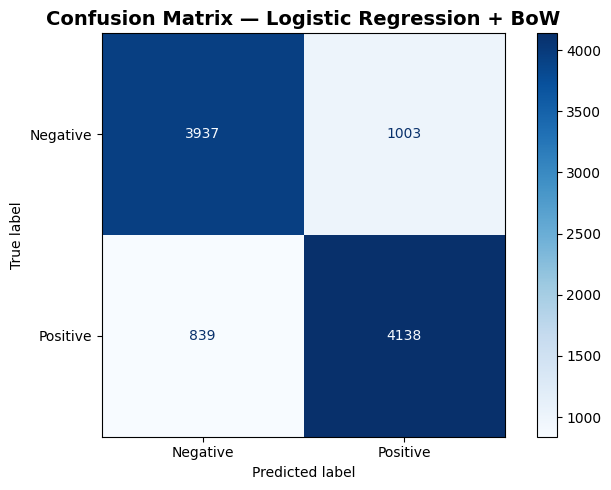

In [36]:
# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix — Logistic Regression + BoW', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Analysis and Discussion

### Observations

- **Bag of Words** with only 300 features provides a compact but limited representation of the text.
- **Logistic Regression** serves as a strong baseline for binary sentiment classification due to its linear decision boundary over sparse feature vectors.
- The model captures the most discriminative high-frequency words but may miss nuances captured by richer representations (e.g., TF-IDF weighting or dense embeddings).

### Limitations

- BoW ignores word order and context, treating each review as an unordered collection of words.
- With only 300 features, many potentially informative words are excluded from the vocabulary.
- Logistic Regression assumes a linear relationship between features and the target, which may not capture complex linguistic patterns.

### Conclusion

This baseline approach demonstrates that even simple feature extraction and classification methods can achieve reasonable performance on sentiment analysis tasks. However, more sophisticated methods (TF-IDF, Word2Vec, GloVe with deep learning models) are expected to improve upon these results.